## 1 · PINNs



> **Definition.** Physics-Informed Neural Networks (PINNs) are specialized AI models that solve complex scientific and engineering problems by embedding the laws of physics directly into the training process. Instead of relying only on historical data, PINNs use known mathematical rules (such as differential equations) as strict guidelines to ensure their predictions make physical sense [1].

Using neural networks to solve differential equations dates back to Lagaris et al. (1998) [5], but the
idea gained momentum after the 2019 paper of Raissi, Perdikaris and Karniadakis [1], which coined the
term PINN. They are now used in fluid dynamics, heat transfer, medical imaging and climate modelling [2].


<div style="text-align:center">
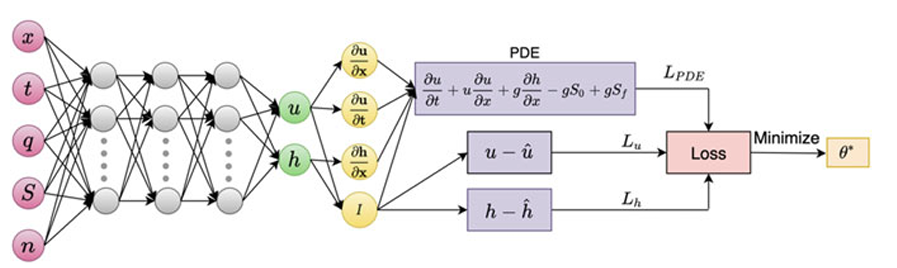
</div>

In [ ]:
# ── Setup: run me first ─────────────────────────────────────────────────────
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)               # reproducible network initialisations
rng = np.random.default_rng(0)     # reproducible synthetic data

# One fixed colour per "actor" — the same in every figure of this notebook
C = {
    "data":   "#0b0b0b",   # black  · measurements
    "true":   "#898781",   # grey   · exact physics (always a dashed line)
    "nn":     "#2a78d6",   # blue   · plain neural network (data only)
    "pinn":   "#1baf7a",   # teal   · physics-informed neural network
    "loss_d": "#eda100",   # yellow · data loss
    "loss_p": "#008300",   # green  · physics loss
    "k":      "#4a3aa7",   # violet · learned physical constant
}

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "xtick.color": "#898781", "ytick.color": "#898781",
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "legend.frameon": False, "figure.dpi": 100,
})

print("PyTorch", torch.__version__, "| NumPy", np.__version__)

## 2 · Model development

### 2.1 Regular MLP

You met the multilayer perceptron in the previous session; here we use the same object with a single
input (time $t$) and a single output (temperature). With two hidden layers,

$$
u_\theta(t) \;=\; W_3\,\sigma\!\Big(W_2\,\sigma\big(W_1\,t + b_1\big) + b_2\Big) + b_3 ,
$$

where the weights and biases are collected in the parameters $\theta$ and $\sigma = \tanh$ is applied
element-wise. By the universal approximation theorem [7], such a network can represent essentially any
smooth function, so it is best pictured as **a curve whose shape we control through $\theta$**.

### 2.2 Training minimises a loss

To make the curve pass through measured points $(t_i, T_i)$ we minimise the mean squared error

$$
\mathcal{L}_{\text{data}}(\theta) \;=\; \frac{1}{N}\sum_{i=1}^{N}\big(u_\theta(t_i) - T_i\big)^2 ,
$$

which is zero exactly when the curve hits every point. Minimisation is by gradient descent,

$$
\theta \;\leftarrow\; \theta - \eta\,\nabla_\theta \mathcal{L},
$$


### 2.3 Automatic differentiation

The fact that makes PINNs possible is this:

> PyTorch can differentiate the network's **output with respect to its input** by applying the chain rule..

So if the network represents a temperature $u_\theta(t)$, PyTorch also gives us $\frac{du_\theta}{dt}$
as a computable function.


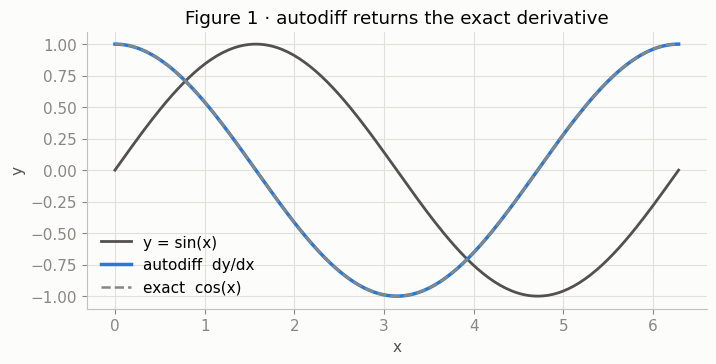

largest difference between autodiff and cos(x): 0.0e+00
no step size h, no approximation — autodiff applied the exact chain rule


In [10]:
# ── Autodiff in one bite: differentiate y = sin(x) without doing any calculus ──
x = torch.linspace(0, 2 * np.pi, 200).reshape(-1, 1)
x.requires_grad_(True)              # "please track operations on x"
y = torch.sin(x)

# Ask PyTorch: "what is dy/dx at every single x?"
dy_dx = torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y))[0]

xd = x.detach()                      # plain numbers again, for plotting
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(xd, y.detach(), color="#52514e", lw=2, label="y = sin(x)")
ax.plot(xd, dy_dx, color=C["nn"], lw=2.5, label="autodiff  dy/dx")
ax.plot(xd, torch.cos(xd), "--", color=C["true"], lw=1.8, label="exact  cos(x)")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Figure 1 · autodiff returns the exact derivative")
ax.legend(loc="lower left")
plt.show()

err = (dy_dx - torch.cos(xd)).abs().max().item()
print(f"largest difference between autodiff and cos(x): {err:.1e}")
print("no step size h, no approximation — autodiff applied the exact chain rule")



* In a PINN we do the same thing to the **network itself**: we differentiate $u_\theta(t)$ with respect
  to $t$ and substitute the result into a physical law.
* This is why we use $\tanh$ rather than ReLU activations: $\tanh$ is smooth, so all derivatives exist
  and carry information.

## 3 · Toy exmpale


Assume we place a temperature sensor in a fresh cup of coffee (95 °C) in a 25 °C room, but the sensor's
battery dies after three minutes. The task is to predict the temperature over the next seven minutes.

According to **Newton's law of cooling** :

$$
\boxed{\;\frac{dT}{dt} \;=\; -\,k\,\big(T(t) - T_{\text{env}}\big)\;}
$$

An equation relating a function to its **rates of change** is an **ordinary
differential equation (ODE)**, and solving it means finding the curve $T(t)$ that obeys it.

| Symbol | Meaning | Value here |
|---|---|---|
| $T(t)$ | coffee temperature at time $t$ | *unknown * |
| $t$ | time in minutes | $0 \le t \le 10$ |
| $T_{\text{env}}$ | room temperature | $25\ ^\circ\mathrm{C}$ |
| $T_0 = T(0)$ | initial temperature | $95\ ^\circ\mathrm{C}$ |
| $k$ | cooling constant (property of the cup) | $0.35\ \text{min}^{-1}$ |

This ODE's solution':

$$
T(t) \;=\; T_{\text{env}} + (T_0 - T_{\text{env}})\,e^{-kt}.
$$

We use this closed form only to grade our networks. Realistic equations (fluid flow, weather, and so
on) have no such formula, which is precisely why numerical methods and PINNs exist.

Below we simulate the experiment: the true curve, together with 12 noisy sensor readings taken only in
the first three minutes.


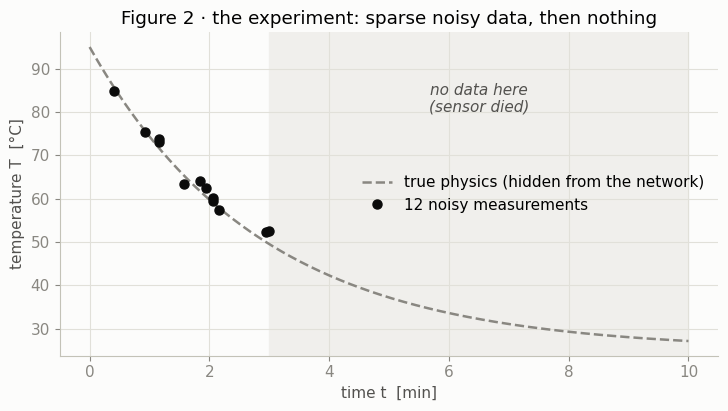

12 measurements between t = 0.41 and t = 2.99 min


In [11]:
# ── Generate the synthetic experiment ──────────────────────────────────────
T_ENV, T0, K_TRUE = 25.0, 95.0, 0.35     # °C, °C, 1/min
T_MAX      = 10.0                        # we want predictions up to 10 min
T_SENSOR   = 3.0                         # ...but the sensor died at 3 min
N_DATA     = 12                          # number of measurements
NOISE_STD  = 1.5                         # sensor noise, °C

def T_exact(t):
    # analytic solution — used ONLY to generate data and to grade our networks
    return T_ENV + (T0 - T_ENV) * np.exp(-K_TRUE * t)

t_data_np = np.sort(rng.uniform(0.0, T_SENSOR, N_DATA))
T_data_np = T_exact(t_data_np) + rng.normal(0.0, NOISE_STD, N_DATA)

# PyTorch wants column tensors of shape (N, 1)
t_data = torch.tensor(t_data_np, dtype=torch.float32).reshape(-1, 1)
T_data = torch.tensor(T_data_np, dtype=torch.float32).reshape(-1, 1)

# A fine grid over the FULL domain, for plotting and grading
t_grid_np = np.linspace(0.0, T_MAX, 300)
t_grid    = torch.tensor(t_grid_np, dtype=torch.float32).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.axvspan(T_SENSOR, T_MAX, color="#f0efec", zorder=0)
ax.plot(t_grid_np, T_exact(t_grid_np), "--", color=C["true"], lw=1.8,
        label="true physics (hidden from the network)")
ax.plot(t_data_np, T_data_np, "o", color=C["data"], ms=6.5, label="12 noisy measurements")
ax.text(6.5, 80, "no data here\n(sensor died)", ha="center",
        color="#52514e", style="italic")
ax.set_xlabel("time t  [min]"); ax.set_ylabel("temperature T  [°C]")
ax.set_title("Figure 2 · the experiment: sparse noisy data, then nothing")
ax.legend()
plt.show()
print(f"{N_DATA} measurements between t = {t_data_np.min():.2f} and t = {t_data_np.max():.2f} min")

## 4 · Plain neural network

At first, we build a network $u_\theta(t)$ and train it on the data
loss alone:

$$
\mathcal{L}(\theta) \;=\; \mathcal{L}_{\text{data}}(\theta)
\;=\; \frac{1}{N}\sum_{i=1}^{N}\big(u_\theta(t_i) - T_i\big)^2 .
$$


In [ ]:
# ── A small multilayer perceptron (MLP): 1 input → 3×32 tanh neurons → 1 output ──
class MLP(nn.Module):
    # t_scale:          input is divided by this (so the net sees numbers ~ 1)
    # u_scale, u_shift: output = u_shift + u_scale * net(...)   (same reason)
    def __init__(self, width=32, depth=3, t_scale=1.0, u_scale=1.0, u_shift=0.0):
        super().__init__()
        self.t_scale, self.u_scale, self.u_shift = t_scale, u_scale, u_shift
        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, t):
        return self.u_shift + self.u_scale * self.net(t / self.t_scale)

def make_coffee_net():
    # fresh network for the coffee problem; re-seed so every experiment
    # starts from the SAME initial weights (fair comparison!)
    torch.manual_seed(0)
    return MLP(width=32, depth=3, t_scale=T_MAX, u_scale=T0 - T_ENV, u_shift=T_ENV)

# n_params = sum(p.numel() for p in make_coffee_net().parameters())
# print(f"our network has {n_params} adjustable parameters (θ)")

iteration     0   data loss =  2791.20  (°C²)
iteration  1000   data loss =     2.77  (°C²)
iteration  2000   data loss =     1.50  (°C²)
iteration  3000   data loss =     1.40  (°C²)
iteration  4000   data loss =     1.35  (°C²)


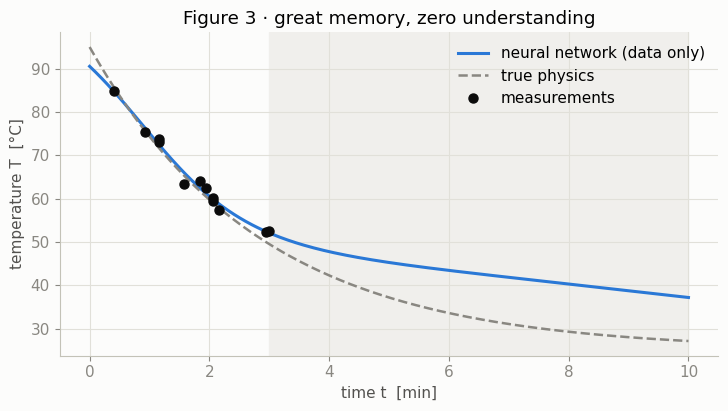

RMSE where we had data      (t ≤ 3):   1.48 °C   ✅
RMSE where we had no data   (t > 3):   9.27 °C   ❌


In [12]:
# ── Train on the data loss alone ────────────────────────────────────────────
nn_model  = make_coffee_net()
optimizer = torch.optim.Adam(nn_model.parameters(), lr=1e-3)

for it in range(4001):
    optimizer.zero_grad()                                # 1. forget old gradients
    loss = torch.mean((nn_model(t_data) - T_data) ** 2)  # 2. data loss
    loss.backward()                                      # 3. gradients via autodiff
    optimizer.step()                                     # 4. one downhill step
    if it % 1000 == 0:
        print(f"iteration {it:5d}   data loss = {loss.item():8.2f}  (°C²)")

with torch.no_grad():                                    # just predicting, no gradients needed
    T_nn = nn_model(t_grid).numpy().ravel()

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.axvspan(T_SENSOR, T_MAX, color="#f0efec", zorder=0)
ax.plot(t_grid_np, T_nn, color=C["nn"], lw=2.2, label="neural network (data only)")
ax.plot(t_grid_np, T_exact(t_grid_np), "--", color=C["true"], lw=1.8, label="true physics")
ax.plot(t_data_np, T_data_np, "o", color=C["data"], ms=6.5, label="measurements")
ax.set_xlabel("time t  [min]"); ax.set_ylabel("temperature T  [°C]")
ax.set_title("Figure 3 · great memory, zero understanding")
ax.legend()
plt.show()

inside  = t_grid_np <= T_SENSOR
rmse_in  = np.sqrt(np.mean((T_nn[inside]  - T_exact(t_grid_np[inside]))  ** 2))
rmse_out = np.sqrt(np.mean((T_nn[~inside] - T_exact(t_grid_np[~inside])) ** 2))
print(f"RMSE where we had data      (t ≤ 3): {rmse_in:6.2f} °C   ✅")
print(f"RMSE where we had no data   (t > 3): {rmse_out:6.2f} °C   ❌")


## 5 · Development of the physics-informed neural network

### The residual: turning an equation into a score

Move every term of the ODE to one side. For any candidate function $u_\theta$ define the **physics
residual**

$$
r_\theta(t) \;=\; \underbrace{\frac{du_\theta}{dt}}_{\text{autodiff}}
\;+\; k\,\big(u_\theta(t) - T_{\text{env}}\big).
$$

If $u_\theta$ obeyed Newton's law exactly, then $r_\theta(t) = 0$ for every $t$, so $|r_\theta(t)|$
measures the physical error at time $t$.

### The physics loss: evaluating the residual on a free grid

Choose $M$ **collocation points** $t_1,\dots,t_M$ spread over the whole domain $[0, 10]$, including the
interval where the sensor was dead, and penalise the residual there:

$$
\mathcal{L}_{\text{physics}}(\theta) \;=\; \frac{1}{M}\sum_{j=1}^{M} r_\theta(t_j)^2 .
$$

The key point is that collocation points need **no measurements**: they are just times at which we ask
the network to obey physics. Physics thus provides unlimited supervision everywhere, for free.

### The total loss

$$
\boxed{\;\mathcal{L}(\theta) \;=\; \mathcal{L}_{\text{data}}(\theta)
\;+\; \lambda\,\mathcal{L}_{\text{physics}}(\theta)\;}
$$

The weight $\lambda$ balances the two objectives, matching the measurements against obeying the
equation ( $\lambda = 1$ is chosen in this exmple).


In [ ]:
# ── Train the PINN: identical network + identical data + ONE extra loss term ──
pinn_model = make_coffee_net()                    # same initial weights as Attempt 1!
optimizer  = torch.optim.Adam(pinn_model.parameters(), lr=1e-3)
LAM   = 1.0                                       # λ, the physics weight
M_COL = 100                                       # number of collocation points

# collocation points cover the WHOLE domain, incl. where the sensor was dead;
# requires_grad=True because we will differentiate the network w.r.t. them
t_col = torch.linspace(0.0, T_MAX, M_COL).reshape(-1, 1).requires_grad_(True)

history = {"data": [], "phys": []}
for it in range(6001):
    optimizer.zero_grad()

    # (a) data loss — exactly as before
    loss_data = torch.mean((pinn_model(t_data) - T_data) ** 2)

    # (b) physics loss — THE PINN MAGIC
    u     = pinn_model(t_col)
    du_dt = torch.autograd.grad(u, t_col, grad_outputs=torch.ones_like(u),
                                create_graph=True)[0]      # du/dt at every t_col
    residual  = du_dt + K_TRUE * (u - T_ENV)               # Newton's law, rearranged
    loss_phys = torch.mean(residual ** 2)

    loss = loss_data + LAM * loss_phys
    loss.backward()
    optimizer.step()

    history["data"].append(loss_data.item())
    history["phys"].append(loss_phys.item())
    if it % 1500 == 0:
        print(f"iteration {it:5d}   data {loss_data.item():8.2f}   physics {loss_phys.item():8.2f}")

# `create_graph=True` keeps the derivative differentiable, so the optimiser can
# backpropagate THROUGH du/dt when minimising the residual.

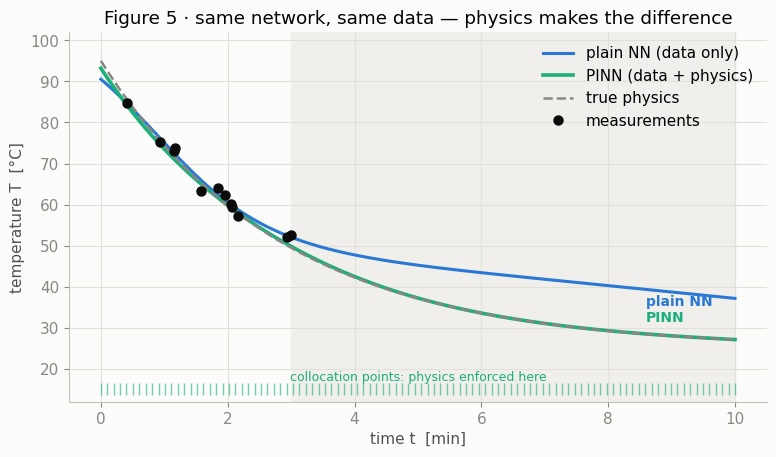

plain NN  extrapolation RMSE (t > 3 min):   9.27 °C
PINN      extrapolation RMSE (t > 3 min):   0.13 °C


In [13]:
# ── Figure 5: the money plot — same network, with vs without physics ─────────
with torch.no_grad():
    T_pinn = pinn_model(t_grid).numpy().ravel()

fig, ax = plt.subplots(figsize=(9, 4.8))
floor = min(T_nn.min(), T_pinn.min(), 20.0) - 8
ax.set_ylim(floor, 102)
ax.axvspan(T_SENSOR, T_MAX, color="#f0efec", zorder=0)

ax.plot(t_grid_np, T_nn,   color=C["nn"],   lw=2.2, label="plain NN (data only)")
ax.plot(t_grid_np, T_pinn, color=C["pinn"], lw=2.6, label="PINN (data + physics)")
ax.plot(t_grid_np, T_exact(t_grid_np), "--", color=C["true"], lw=1.8, label="true physics")
ax.plot(t_data_np, T_data_np, "o", color=C["data"], ms=6.5, label="measurements")

# where physics was enforced (collocation points), as a rug along the bottom
ax.plot(t_col.detach().numpy().ravel(), np.full(M_COL, floor + 3), "|", ms=9,
        color=C["pinn"], alpha=0.6)
ax.text(5.0, floor + 5.2, "collocation points: physics enforced here",
        fontsize=9, color=C["pinn"], ha="center")

ax.annotate("plain NN", (8.6, np.interp(8.6, t_grid_np, T_nn) - 4),
            color=C["nn"], fontsize=10, weight="bold")
ax.annotate("PINN", (8.6, np.interp(8.6, t_grid_np, T_pinn) + 3),
            color=C["pinn"], fontsize=10, weight="bold")

ax.set_xlabel("time t  [min]"); ax.set_ylabel("temperature T  [°C]")
ax.set_title("Figure 5 · same network, same data — physics makes the difference")
ax.legend(loc="upper right")
plt.show()

out = t_grid_np > T_SENSOR
for name, pred in [("plain NN", T_nn), ("PINN    ", T_pinn)]:
    rmse = np.sqrt(np.mean((pred[out] - T_exact(t_grid_np[out])) ** 2))
    print(f"{name}  extrapolation RMSE (t > 3 min): {rmse:6.2f} °C")

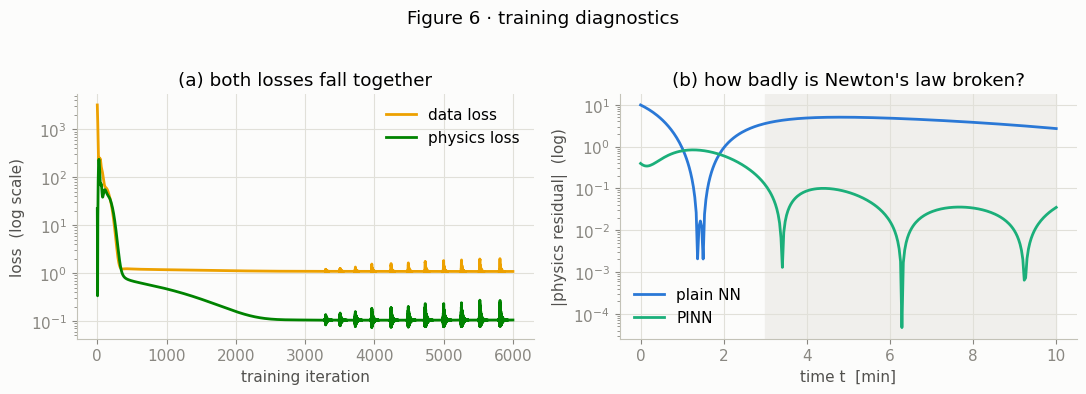

In [14]:
# ── Figure 6: what happened during training, and where is physics violated? ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))

its = np.arange(len(history["data"]))
ax1.semilogy(its, history["data"], color=C["loss_d"], lw=2, label="data loss")
ax1.semilogy(its, history["phys"], color=C["loss_p"], lw=2, label="physics loss")
ax1.set_xlabel("training iteration"); ax1.set_ylabel("loss  (log scale)")
ax1.set_title("(a) both losses fall together")
ax1.legend()

# evaluate the physics residual r(t) of BOTH trained models on a fine grid
t_r = torch.linspace(0.0, T_MAX, 300).reshape(-1, 1).requires_grad_(True)
for model, key, label in [(nn_model, "nn", "plain NN"), (pinn_model, "pinn", "PINN")]:
    u  = model(t_r)
    du = torch.autograd.grad(u, t_r, grad_outputs=torch.ones_like(u))[0]
    r  = (du + K_TRUE * (u - T_ENV)).detach().numpy().ravel()
    ax2.semilogy(t_r.detach().numpy().ravel(), np.abs(r) + 1e-12,
                 color=C[key], lw=2, label=label)
ax2.axvspan(T_SENSOR, T_MAX, color="#f0efec", zorder=0)
ax2.set_xlabel("time t  [min]"); ax2.set_ylabel("|physics residual|  (log)")
ax2.set_title("(b) how badly is Newton's law broken?")
ax2.legend()
fig.suptitle("Figure 6 · training diagnostics", y=1.03)
plt.tight_layout()
plt.show()

The inverse problem: *discovering* a physical constant from data

So far the cooling constant $k$ was assumed known. In practice, constants like $k$ (or a material's
conductivity, a drug's clearance rate, an epidemic's infection rate) are exactly what experiments set
out to measure. PINNs handle this naturally: **declare $k$ a trainable parameter** and let the
optimiser tune it alongside the network weights,

$$
\min_{\theta,\,k}\;\;\mathcal{L}_{\text{data}}(\theta)
\;+\; \lambda\,\frac{1}{M}\sum_{j=1}^{M}\Big(\frac{du_\theta}{dt}(t_j) + k\big(u_\theta(t_j)-T_{\text{env}}\big)\Big)^2 .
$$

The idea: the data term forces $u_\theta$ to match the measurements, and the physics term is then only
satisfiable when $k$ takes the value that makes Newton's law agree with those measurements.

*(Implementation note: we train $\log k$ and set $k = e^{\log k}$, which keeps $k > 0$; a negative
cooling constant would mean the coffee heats up on its own.)*


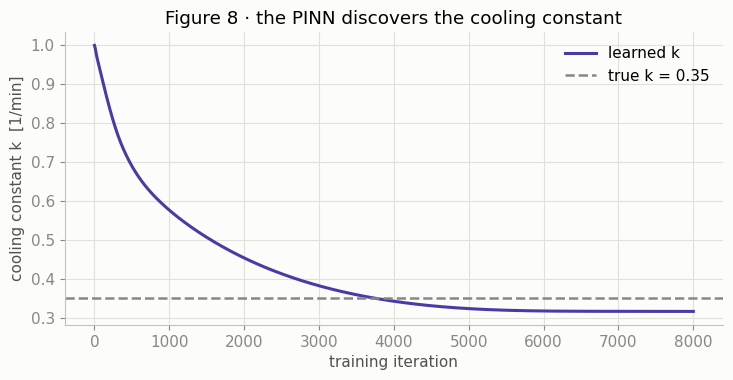

learned k = 0.3161   (true value 0.35; error 9.7%, limited by sensor noise)


In [15]:
# ── Bonus B: recover k from the 12 noisy measurements (~15 s) ────────────────
torch.manual_seed(0)
inv_model = make_coffee_net()
log_k     = nn.Parameter(torch.tensor(0.0))            # start guess: k = e^0 = 1.0
optimizer = torch.optim.Adam(list(inv_model.parameters()) + [log_k], lr=1e-3)

t_col = torch.linspace(0.0, T_MAX, 100).reshape(-1, 1).requires_grad_(True)
k_history = []
for it in range(8001):
    optimizer.zero_grad()
    k = torch.exp(log_k)
    loss_data = torch.mean((inv_model(t_data) - T_data) ** 2)
    u  = inv_model(t_col)
    du = torch.autograd.grad(u, t_col, torch.ones_like(u), create_graph=True)[0]
    loss_phys = torch.mean((du + k * (u - T_ENV)) ** 2)  # note: k is now unknown!
    (loss_data + loss_phys).backward()
    optimizer.step()
    k_history.append(torch.exp(log_k).detach().item())   # record k after each step

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.plot(k_history, color=C["k"], lw=2.2, label="learned k")
ax.axhline(K_TRUE, ls="--", color=C["true"], lw=1.8, label=f"true k = {K_TRUE}")
ax.set_xlabel("training iteration"); ax.set_ylabel("cooling constant k  [1/min]")
ax.set_title("Figure 8 · the PINN discovers the cooling constant")
ax.legend()
plt.show()
print(f"learned k = {k_history[-1]:.4f}   (true value {K_TRUE}; "
      f"error {100*abs(k_history[-1]-K_TRUE)/K_TRUE:.1f}%, limited by sensor noise)")


## References

[1] M. Raissi, P. Perdikaris & G. E. Karniadakis, *Physics-informed neural networks: A deep learning
framework for solving forward and inverse problems involving nonlinear partial differential
equations*, *Journal of Computational Physics* **378**, 686–707 (2019).
[doi:10.1016/j.jcp.2018.10.045](https://doi.org/10.1016/j.jcp.2018.10.045)

[2] G. E. Karniadakis, I. G. Kevrekidis, L. Lu, P. Perdikaris, S. Wang & L. Yang, *Physics-informed
machine learning*, *Nature Reviews Physics* **3**, 422–440 (2021).
[doi:10.1038/s42254-021-00314-5](https://doi.org/10.1038/s42254-021-00314-5)

[3] B. Moseley, *So, what is a physics-informed neural network?* (blog post, 2021).
[benmoseley.blog](https://benmoseley.blog/my-research/so-what-is-a-physics-informed-neural-network/) ·
[github.com/benmoseley/harmonic-oscillator-pinn](https://github.com/benmoseley/harmonic-oscillator-pinn)

[4] L. Lu, X. Meng, Z. Mao & G. E. Karniadakis, *DeepXDE: A deep learning library for solving
differential equations*, *SIAM Review* **63**(1), 208–228 (2021).
[doi:10.1137/19M1274067](https://doi.org/10.1137/19M1274067) ·
[deepxde.readthedocs.io](https://deepxde.readthedocs.io)

[5] I. E. Lagaris, A. Likas & D. I. Fotiadis, *Artificial neural networks for solving ordinary and
partial differential equations*, *IEEE Transactions on Neural Networks* **9**(5), 987–1000 (1998).
[doi:10.1109/72.712178](https://doi.org/10.1109/72.712178)

[6] A. G. Baydin, B. A. Pearlmutter, A. A. Radul & J. M. Siskind, *Automatic differentiation in
machine learning: a survey*, *Journal of Machine Learning Research* **18**(153), 1–43 (2018).
[jmlr.org/papers/v18/17-468](https://jmlr.org/papers/v18/17-468.html)

[7] G. Cybenko, *Approximation by superpositions of a sigmoidal function*, *Mathematics of Control,
Signals and Systems* **2**, 303–314 (1989); K. Hornik, *Approximation capabilities of multilayer
feedforward networks*, *Neural Networks* **4**(2), 251–257 (1991).

[8] S. Wang, Y. Teng & P. Perdikaris, *Understanding and mitigating gradient flow pathologies in
physics-informed neural networks*, *SIAM Journal on Scientific Computing* **43**(5), A3055–A3081
(2021). [doi:10.1137/20M1318043](https://doi.org/10.1137/20M1318043)

[9] D. P. Kingma & J. Ba, *Adam: A method for stochastic optimization*, ICLR (2015).
[arXiv:1412.6980](https://arxiv.org/abs/1412.6980)

